# Time Series Analysis: Representation

In [1]:
# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Let's load a classic periodic time series example showing trend and seasonality: The Airline Passenger Dataset recording passengers per day. We can observe how the overall passenger count as well as the amplitude size increase over time.

       Passengers
count     144.000
mean      280.299
std       119.966
min       104.000
25%       180.000
50%       265.500
75%       360.500
max       622.000


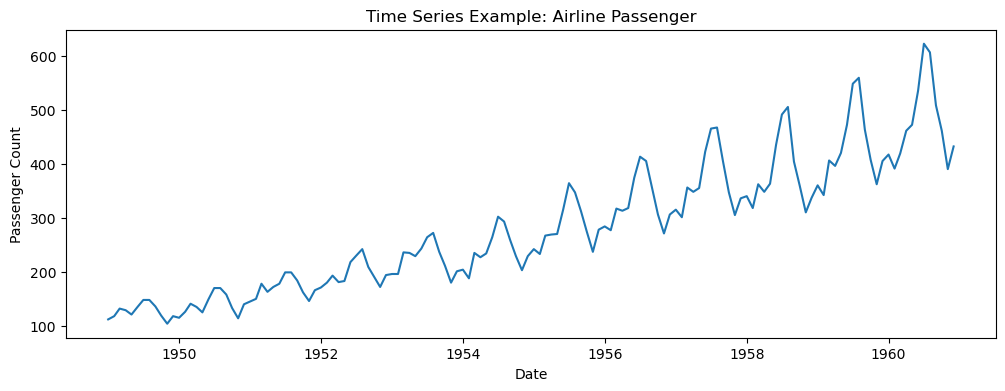

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
ts_example = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# some statistics of the original time series
print(ts_example.describe().round(3))

# plot of the time series
plt.figure(figsize=(12, 4))
plt.plot(ts_example)
plt.title("Time Series Example: Airline Passenger")
plt.xlabel("Date")
plt.ylabel("Passenger Count")
plt.show()

## 1. Normalization
As time series can have a difference in values due to the underlying scale or other reasons, normalizing them for comparison can be useful. Two of the most used normalization techniques are min-max and z-normalization. 

Min-Max-Normalization uses the min and max values of the time series to fit it into the range of [0,1] with the min always being mapped to 0 and the max to 1. In comparison to z-normalization, mean and standard deviation are not standardised.

In [3]:
def min_max_norm(time_series):
    ts_min = np.min(time_series)
    ts_max = np.max(time_series)
    
    return (time_series - ts_min) / (ts_max - ts_min)

# other options: sklearn.preprocessing.normalize, sklearn.preprocessing.MinMaxScaler
ts_min_max = min_max_norm(ts_example)

print(pd.DataFrame(ts_min_max).describe().round(3))

       Passengers
count     144.000
mean        0.340
std         0.232
min         0.000
25%         0.147
50%         0.312
75%         0.495
max         1.000


Z-Normalization shifts the time series in a way that makes it have a mean of 0 and a standard deviation of 1. 

When the function is supposed to accept any time series, it is important to handle constant series. They have a standard deviation of 0, which would break the division. One can either check for a constant series in the beginning or add a very small number to the denominator which does not influence regular values too much but division safe.

In [ ]:
def znorm(time_series):
    ts_mean = np.mean(time_series)
    ts_std = np.std(time_series)

    return (time_series - ts_mean) / (ts_std + 1e-8)

# other options: sklearn.preprocessing.normalize, sklearn.preprocessing.StandardScaler
ts_znormed = znorm(ts_example)

print(pd.DataFrame(ts_znormed).describe().round(2))

       Passengers
count      144.00
mean         0.00
std          1.00
min         -1.47
25%         -0.84
50%         -0.12
75%          0.67
max          2.86


Lets compare the two normalizations: Notice, how z-normalization doesn't bound the values per se. Furthermore, we can still observe the bijective property of both normalizations, e.g. how peaks and valleys align.

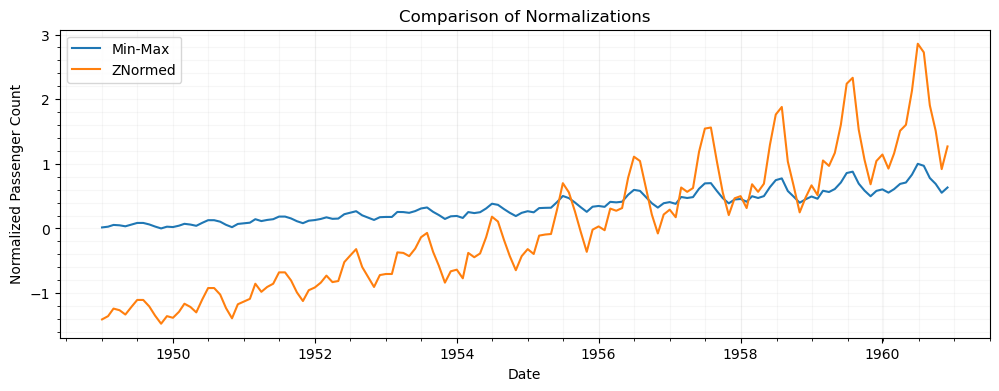

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(ts_min_max, label='Min-Max')
plt.plot(ts_znormed, label='ZNormed')

plt.title("Comparison of Normalizations")
plt.xlabel("Date")
plt.ylabel("Normalized Passenger Count")
plt.legend()

plt.minorticks_on()
plt.grid(which="both", alpha=0.1)
plt.show()

## 2. Representation

As time series can grow up to extreme size, representation techniques are getting more and more important. They can allow the time series to be stored more memory efficient (dimensionality reduction) or support different analysation techniques through their structure.

From the several shown representation techniques in the lecture, we will implement the following three:
1. DFT (Discrete Fourier Transformation)
2. PAA (Piecewise Aggregate Approximation)
3. SAX (Symbolic Aggregate Approximation)

### 2.1. DFT

!!TODO: intuitive, correct explanation of DFT!!

Discrete Fourier Transformation is a way to represent a discrete set of points as a sum of trigonometric, i.e. sinus and cosinus functions. The formula for DFT is 

$$ X_k = \sum_{n=0}^{N-1} x_n \cdot e^{-i2\pi \frac{k}{N}n}$$

where 
- $X_k$ is a complex number that tells us the amplitude and phase of the k'th frequency
- $\sum_{n=0}^{N-1} x_n$ says that we are aggregating information from all our data points
- $e^{-i2\pi}$ describes that we are using sinoidal functions. It is simply a practical way to express a circle mathematically.
- $\frac{k}{N}n$

It transforms the input into complex numbers which store the contribution of each evaluated frequency. 

Fast Fourier Transformation (FFT) is only an algebraic trick on the DFT formula, because the latter uses several computations multiple times. By efficiently reorganizing those computations, one can lower the runtime from $\mathcal{O}(n^2)$ to $\mathcal{O}(n \log n)$. Because FFT is so widely applied, the term is commenly used interchangeably with DFT.

The first 5 values of the DFT:
(40363+0j)
(855.03+8906.56j)
(-48.12+4098.7j)
(517.59+3225.75j)
(-137.08+2323.01j)

 The positive frequencies which were evaluated:
[0.         0.00694444 0.01388889 0.02083333 0.02777778 0.03472222
 0.04166667 0.04861111 0.05555556 0.0625     0.06944444 0.07638889
 0.08333333 0.09027778 0.09722222 0.10416667 0.11111111 0.11805556
 0.125      0.13194444 0.13888889 0.14583333 0.15277778 0.15972222
 0.16666667 0.17361111 0.18055556 0.1875     0.19444444 0.20138889
 0.20833333 0.21527778 0.22222222 0.22916667 0.23611111 0.24305556
 0.25       0.25694444 0.26388889 0.27083333 0.27777778 0.28472222
 0.29166667 0.29861111 0.30555556 0.3125     0.31944444 0.32638889
 0.33333333 0.34027778 0.34722222 0.35416667 0.36111111 0.36805556
 0.375      0.38194444 0.38888889 0.39583333 0.40277778 0.40972222
 0.41666667 0.42361111 0.43055556 0.4375     0.44444444 0.45138889
 0.45833333 0.46527778 0.47222222 0.47916667 0.48611111 0.49305556
 0.5       ]


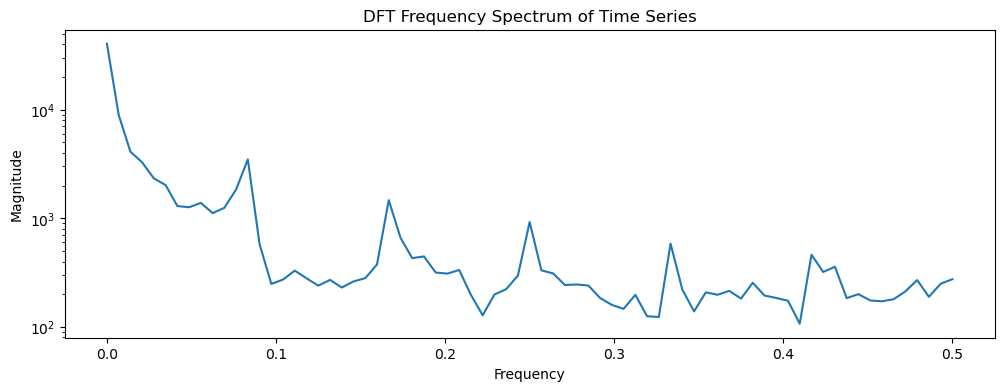

In [ ]:
# We are using rfft (real fft) and its associate functions 
# as real world signals usually don't contain complex numbers
from scipy.fft import rfft, rfftfreq, irfft

N = len(ts_example)
yf = rfft(ts_example.Passengers.copy()) # Result of the fft
xf = rfftfreq(N)                        # The frequencies which were evaluated

print("The first 5 values of the DFT:")
print(*yf[:5].round(2), sep="\n")

print("\n The positive frequencies which were evaluated:")
print(xf)

plt.figure(figsize=(12, 4))
plt.plot(xf, np.abs(yf))

plt.title("DFT Frequency Spectrum of Time Series")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.yscale("log")
plt.show()

The frequency distribution in this example is quite spread out, thus the log scale. Below is another example for a function derived directly from trigonometric functions. This creates a way clearer spectrum:

In [ ]:
signal = 

N = len(ts_example)
signalf = rfft(signal) # Result of the fft
xf = rfftfreq(N)                        # The frequencies which were evaluated

print("The first 5 values of the DFT:")
print(*yf[:5].round(2), sep="\n")

print("\n The positive frequencies which were evaluated:")
print(xf)

plt.figure(figsize=(12, 4))
plt.plot(xf, np.abs(yf))

plt.title("DFT Frequency Spectrum of Time Series")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.yscale("log")
plt.show()

From the DFT we can extract the dominant frequencies. In the plot above, the most dominant frequency is at about ~0.85 and the subsequent spikes are approximately multiples of that value.

In [7]:
def reduce_dims(yf, dims):
    # 1: get the contribution of each frequency
    magnitudes = np.abs(yf)

    # 2: Find the indices of the top N dominant frequencies
    freqs_to_keep = dims 
    top_indices = np.argsort(magnitudes)[-freqs_to_keep:]

    # 3: Create a filtered FFT array (zeroing out the rest)
    yf_reduced = np.zeros_like(yf)
    yf_reduced[top_indices] = yf[top_indices]

    return yf_reduced

From these we can simply recreate a signal with the inverse FFT. If frequencies have been removed, the signal often looses some of its complexity. 

The first plot shows the "DC-Term" (coming from AC/DC in electricity, where DFT is often applied). The DC-Term describes the general offset of the data, being a sum of all frequency magnitudes.

The other three show ever more included frequencies in the reduced signal. Thus, they are being closer to the original time series. Keeping all frequencies would result in a perfect inversion.

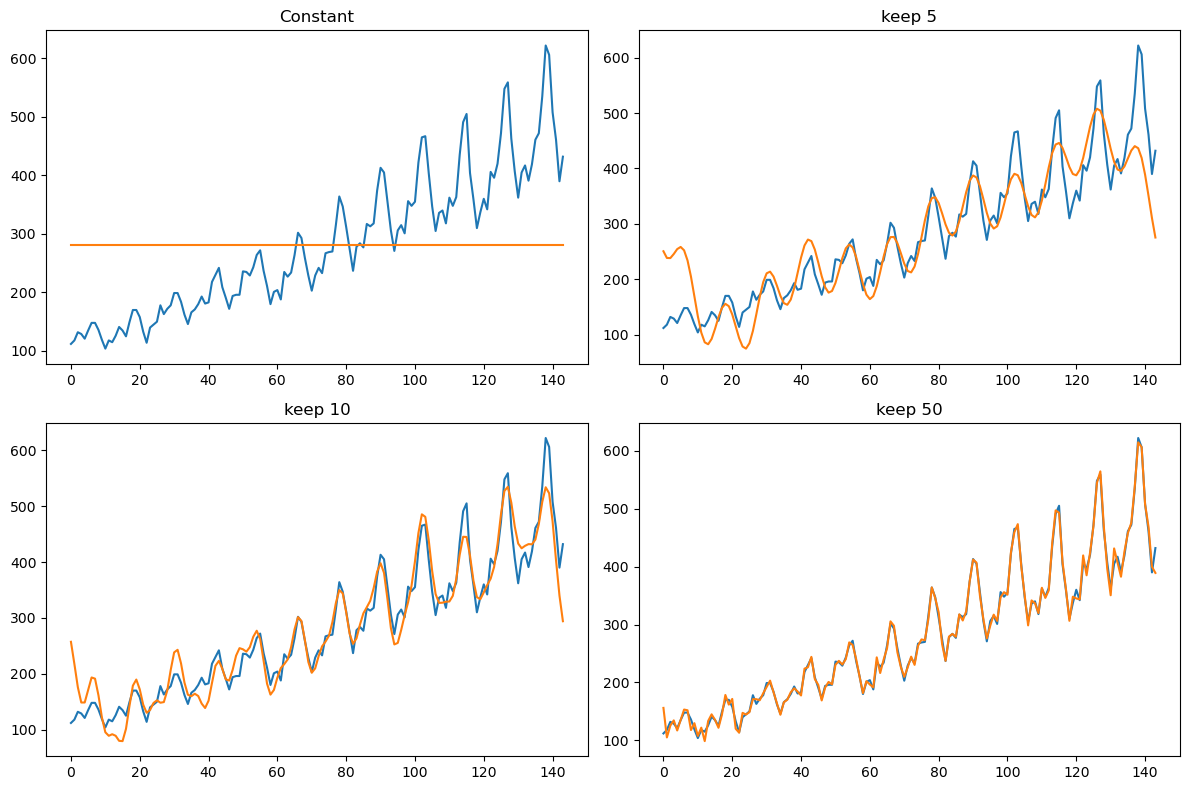

In [8]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(ts_example.reset_index(drop=True))
plt.plot(irfft(reduce_dims(yf, 1), n=N))
plt.title("Constant")

plt.subplot(2, 2, 2)
plt.plot(ts_example.reset_index(drop=True))
plt.plot(irfft(reduce_dims(yf, 5), n=N))
plt.title("keep 5")

plt.subplot(2, 2, 3)
plt.plot(ts_example.reset_index(drop=True))
plt.plot(irfft(reduce_dims(yf, 10), n=N))
plt.title("keep 10")

plt.subplot(2, 2, 4)
plt.plot(ts_example.reset_index(drop=True))
plt.plot(irfft(reduce_dims(yf, 50), n=N))
plt.title("keep 50")

plt.tight_layout()
plt.show()

### 2.2. PAA

Piecewise Aggregate Approximation aggregates the values within each tumbling window. 

The window size controls how many data points are averaged at once. It is important to keep the window size when reducing the data as it is essential to store information about the original length of the time series.

In [ ]:
# or use pyts.pproximation.PiecewiseAggregateApproximation
def paa(X, window_size):
    # 1: calculate new shape
    n_timestamps_new = len(X) // window_size
    X_paa = np.empty(n_timestamps_new)

    # 2: average within each window
    for j in range(n_timestamps_new):
        X_subsequence = X[j*window_size:(j+1)*window_size] # one window
        X_paa[j] = np.mean(X_subsequence) 
    
    return X_paa

Lets look at some window sizes to see how they affect the PAA function. One can observe the correlation between saved memory and precision loss:

A window size of 2 approximates the time series pretty well, but offers little dimensionality reduction.

A window size of 16, which is around 10% of the number of datapoints in the time series, is unable to capture any valleys. It reduces to a step function.

The correct choice of the window size is memory and data dependent. There are time series which allow such a relatively big window size without loosing important characteristics.

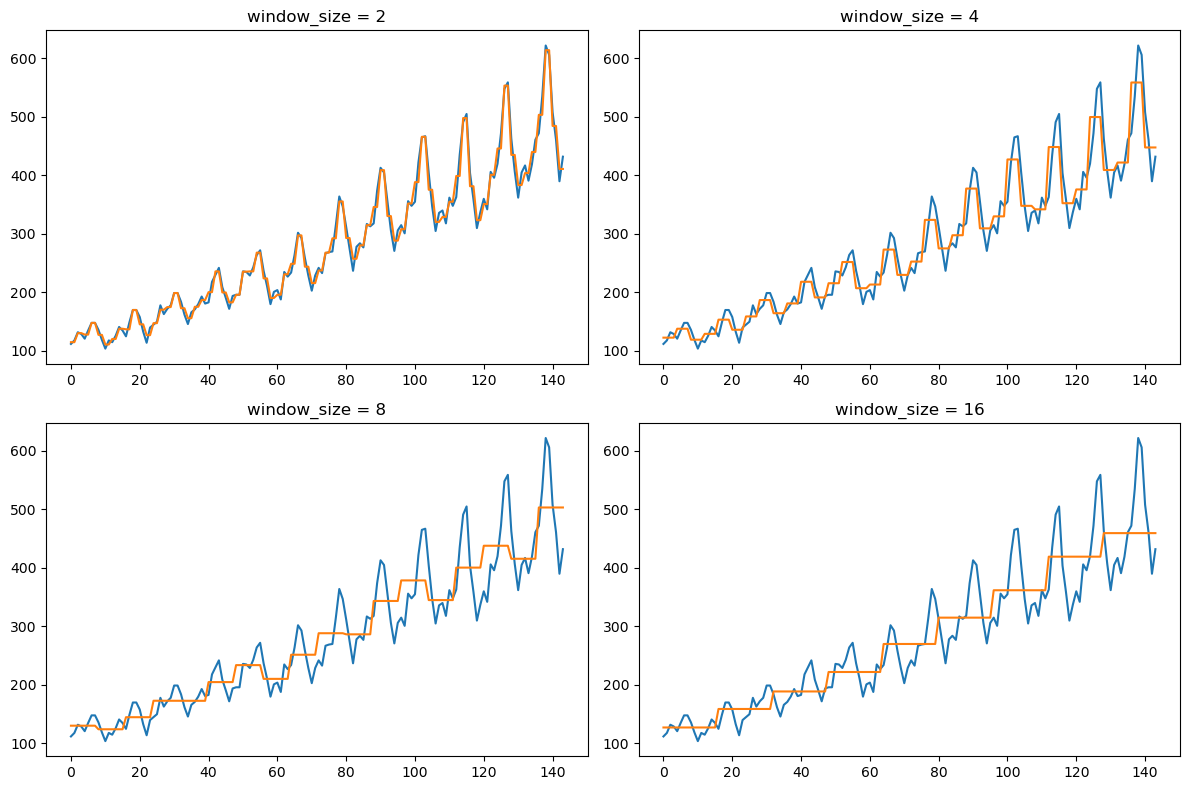

In [10]:
ts_paa_2 = paa(ts_example, 2)
ts_paa_4 = paa(ts_example, 4)
ts_paa_8 = paa(ts_example, 8)
ts_paa_16 = paa(ts_example, 16)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(ts_example.reset_index(drop=True))
plt.plot(np.repeat(ts_paa_2, 2))            # we have to repeat each value to get to the original length
plt.title("window_size = 2")

plt.subplot(2, 2, 2)
plt.plot(ts_example.reset_index(drop=True))
plt.plot(np.repeat(ts_paa_4, 4))            # we have to repeat each value to get to the original length
plt.title("window_size = 4")

plt.subplot(2, 2, 3)
plt.plot(ts_example.reset_index(drop=True))
plt.plot(np.repeat(ts_paa_8, 8))            # we have to repeat each value to get to the original length
plt.title("window_size = 8")

plt.subplot(2, 2, 4)
plt.plot(ts_example.reset_index(drop=True))
plt.plot(np.repeat(ts_paa_16, 16))          # we have to repeat each value to get to the original length
plt.title("window_size = 16")

plt.tight_layout()
plt.show()

Comparing PAA to DFT:

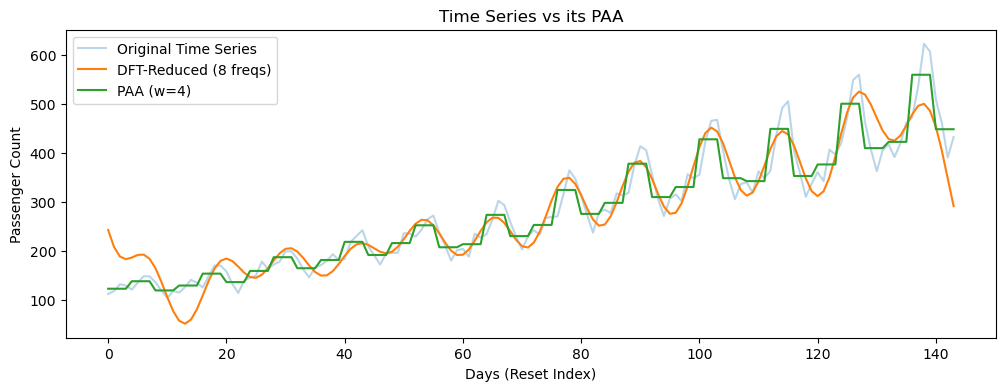

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(ts_example.reset_index(drop=True), label="Original Time Series", alpha=0.3)
plt.plot(irfft(reduce_dims(rfft(ts_example.Passengers.copy()), 8), n=N), label="DFT-Reduced (8 freqs)") # TS -> DFT -> Reduce -> Reverse
plt.plot(np.repeat(paa(ts_example, 4), 4), label="PAA (w=4)")

plt.title("Time Series vs its PAA")
plt.xlabel("Days (Reset Index)")
plt.ylabel("Passenger Count")
plt.legend()
plt.show()

### 2.3. SAX

SAX is an evolution of PAA. It takes the averaged PAA segments and maps them to discrete characters (a, b, c...) based on Gaussian probability bins

In [12]:
import string
from scipy.stats import norm

# or use pyts.approximation.SymbolicAggregateApproximation
def sax(X, window_size, n_bins, return_paa=False):
    # 1: Prepare symbols
    alphabet = list(string.ascii_lowercase)
    bins = np.array(alphabet[:n_bins]) # Converted to numpy array for fast indexing

    # 2: Perform PAA to get averaged results
    X_paa = paa(X, window_size)
    
    # 3: Calculate equiprobable breakpoints using the normal distribution
    breakpoints = norm.ppf(np.linspace(0, 1, n_bins + 1)[1:-1])

    # 4: Convert values into letters
    indices = np.searchsorted(breakpoints, X_paa.copy(), side='left')  # map value to a bin index
    sax_symbols = bins[indices]                                 # use indices to fetch the corresponding letters

    if return_paa:
        return X_paa, np.array(sax_symbols) # for plotting
    else:
        return np.array(sax_symbols)

Now we are able to create the SAX from the time series. The SAX algorithm assumes a z-normalized input.

If the PAA produces a granular enough reprentation, adjacent peaks and valleys can map to different symbols.

The resulting SAX String:
aaaaaaaaaaaaaaaaabbaabbabbcbbccbbccbcccccccccccc


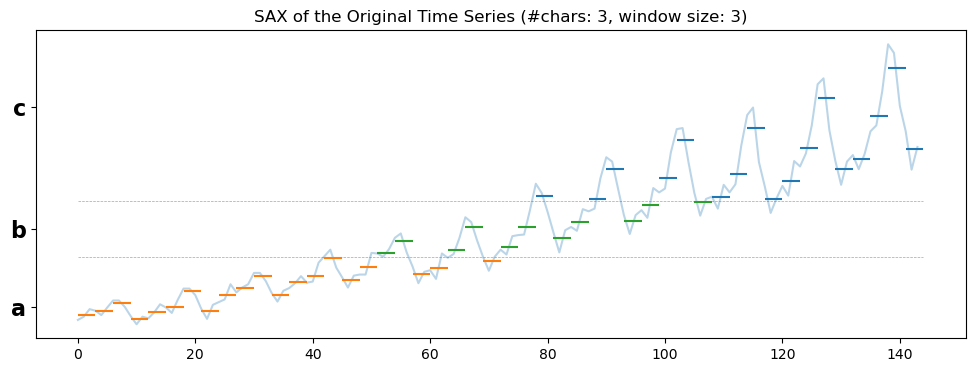

In [13]:
n_bins = 3
window_size = 3

X_paa, X_sax = sax(znorm(ts_example), window_size=window_size, n_bins=n_bins, return_paa=True)

# print the SAX string
print("The resulting SAX String:")
print("".join(X_sax))

# plot SAX on original time series
plt.figure(figsize=(12, 4))
plt.plot(znorm(ts_example.reset_index(drop=True)), alpha=0.3)

bins = norm.ppf(np.linspace(0, 1, n_bins + 1)[1:-1])
plt.hlines(bins, 0, len(ts_example), color='g', linestyles='--', linewidth=0.5, alpha=0.5)

cmap = plt.get_cmap('tab10')
plt.hlines(X_paa, 
           [i * window_size for i in range(len(X_paa))], 
           [(i+1) *window_size for i in range(len(X_paa))],
           colors=[cmap(ord(char) % n_bins) for char in X_sax]
           )

y_min = znorm(ts_example).min() - 0.5
y_max = znorm(ts_example).max() + 0.5
extended_bounds = np.concatenate((y_min, bins, y_max))
bin_centers = (extended_bounds[:-1] + extended_bounds[1:]) / 2
plt.yticks(ticks=bin_centers, labels=np.unique(X_sax), fontsize=16, fontweight='bold')
plt.title(f"SAX of the Original Time Series (#chars: {n_bins}, window size: {window_size})")
plt.show()